In [1]:
!pip install torchinfo
!pip install --quiet torchview graphviz

In [2]:
import math
import os
import time
from datetime import timedelta
import random

import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt
from IPython.display import SVG, display

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from torchinfo import summary
from torchview import draw_graph

import torchvision.models as models

In [3]:
ROOT_DIR = '/kaggle/input/competitions/aptos2019-blindness-detection'
IMG_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 4
RANDOM_STATE = 42

In [4]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

ROOT_DIR = "/kaggle/input/competitions/aptos2019-blindness-detection"   # change if needed


# =========================
# APTOS CSV LOADER
# =========================
def load_aptos_annotations(root_dir,
                           csv_name="train.csv",
                           image_folder="train_images"):
    """
    Load APTOS 2019 annotations from train.csv
    
    Returns dataframe with:
    image_path | label
    """

    csv_path = os.path.join(root_dir, csv_name)

    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"{csv_path} not found")

    df = pd.read_csv(csv_path)

    required_cols = ["id_code", "diagnosis"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing column: {col}")

    records = []
    missing_images = 0

    for _, row in df.iterrows():
        img_id = str(row["id_code"]).strip()
        label = int(row["diagnosis"])

        img_path = os.path.join(root_dir, image_folder, img_id + ".png")

        if os.path.isfile(img_path):
            records.append((img_path, label))
        else:
            missing_images += 1

    df_records = pd.DataFrame(records, columns=["image_path", "label"])

    print("========== DATA SUMMARY ==========")
    print("Loaded images:", len(df_records))
    print("Missing images:", missing_images)
    print("Class distribution:")
    print(df_records["label"].value_counts().sort_index())
    print("==================================")

    return df_records


# =========================
# LOAD DATA
# =========================
df_all = load_aptos_annotations(ROOT_DIR)


# =========================
# CLASSES (APTOS = 5)
# =========================
CLASSES = [
    "No DR",
    "Mild",
    "Moderate",
    "Severe",
    "Proliferative DR"
]

num_classes = len(CLASSES)


# =========================
# TRAIN / VAL / TEST SPLIT
# =========================
train_df, temp_df = train_test_split(
    df_all,
    test_size=0.30,
    stratify=df_all["label"],
    random_state=RANDOM_STATE
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=RANDOM_STATE
)

print("\nSplit sizes:")
print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

========== DATA SUMMARY ==========
Loaded images: 3662
Missing images: 0
Class distribution:
label
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64

Split sizes:
Train: 2563
Val: 549
Test: 550


In [5]:
class AptosDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'image_path']
        label = self.df.loc[idx, 'label']

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

In [6]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

In [7]:
train_dataset = AptosDataset(train_df, transform=transform)
val_dataset = AptosDataset(val_df, transform=transform)
test_dataset = AptosDataset(test_df, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

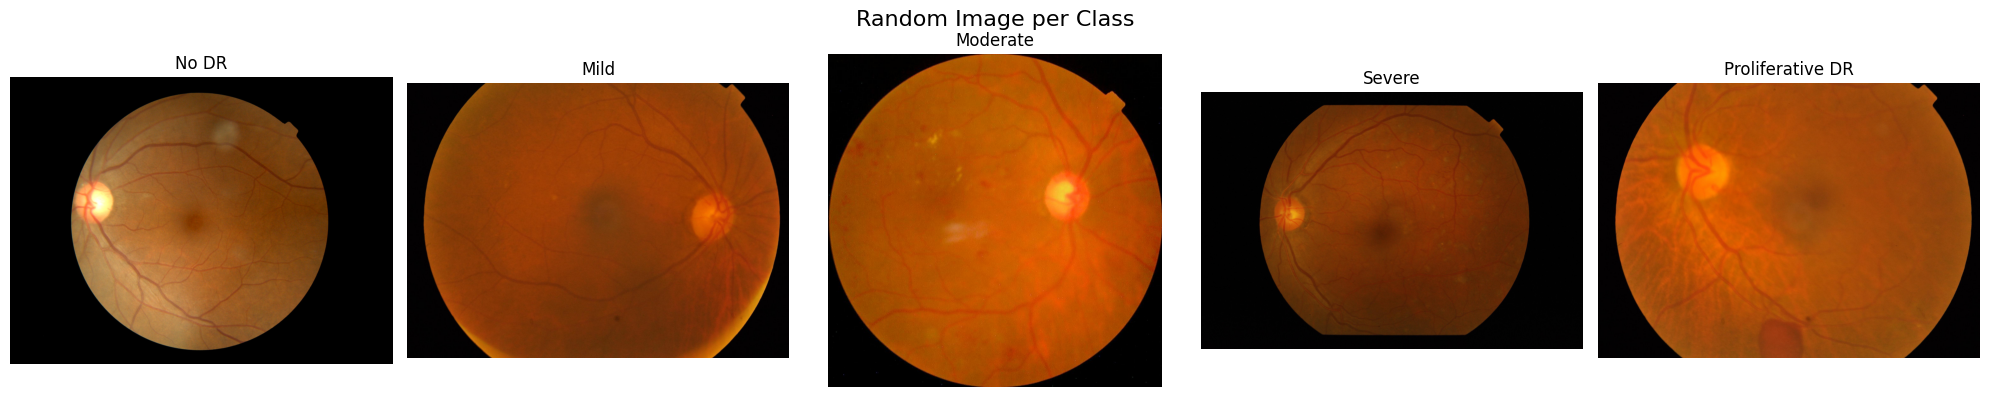

In [8]:
def show_random_images_per_class(df, classes, title="Random Image per Class"):
    num_classes = len(classes)
    fig, axs = plt.subplots(1, num_classes, figsize=(4 * num_classes, 4))
    if num_classes == 1:
        axs = [axs]

    for i, cls in enumerate(range(num_classes)):
        class_df = df[df['label'] == cls]
        if len(class_df) == 0:
            axs[i].axis("off")
            axs[i].set_title(f"{classes[cls]}\n(No Images)")
            continue

        row = class_df.sample(n=1).iloc[0]
        image = Image.open(row['image_path']).convert('RGB')
        axs[i].imshow(image)
        axs[i].set_title(classes[cls], fontsize=12)
        axs[i].axis('off')

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()
show_random_images_per_class(train_df, CLASSES)

In [9]:
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()

        self.conv = nn.Conv2d(
            2, 1,
            kernel_size=kernel_size,
            padding=kernel_size // 2,
            bias=False
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Channel-wise pooling
        avg_pool = torch.mean(x, dim=1, keepdim=True)      # (B,1,H,W)
        max_pool, _ = torch.max(x, dim=1, keepdim=True)    # (B,1,H,W)

        # Concatenate
        x_cat = torch.cat([avg_pool, max_pool], dim=1)     # (B,2,H,W)

        # Conv + Sigmoid
        attention = self.sigmoid(self.conv(x_cat))         # (B,1,H,W)

        # Apply attention
        return x * attention                               # (B,C,H,W)

In [10]:
class EfficientNet_Fusion(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # Backbone
        self.backbone = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.DEFAULT
        )
        self.features = self.backbone.features

        # Spatial Attention
        self.sa = SpatialAttention()

        # Global pooling
        self.global_pool = nn.AdaptiveAvgPool2d(1)

        # Final classifier (1280 + 112 = 1392)
        self.classifier = nn.Linear(1280 + 112, num_classes)

    def forward(self, x):

        spatial_feat = None

        # ===== Feature Extraction =====
        for i, layer in enumerate(self.features):
            x = layer(x)

            # Capture intermediate feature (14x14x112)
            if i == 5:
                spatial_feat = x

        # ===== Branch 1: Global =====
        global_feat = self.global_pool(x)           # (B,1280,1,1)
        global_feat = torch.flatten(global_feat, 1) # (B,1280)

        # ===== Branch 2: Spatial Attention =====
        spatial_feat = self.sa(spatial_feat)        # (B,112,14,14)
        spatial_feat = self.global_pool(spatial_feat) # (B,112,1,1)
        spatial_feat = torch.flatten(spatial_feat, 1) # (B,112)

        # ===== Fusion =====
        fused = torch.cat([global_feat, spatial_feat], dim=1)  # (B,1392)

        # ===== Classification =====
        out = self.classifier(fused)

        return out

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EfficientNet_Fusion(num_classes).to(device)
model.to(device)
summary(model, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                                  Output Shape              Param #
EfficientNet_Fusion                                     [1, 5]                    1,281,000
├─Sequential: 1-1                                       --                        --
│    └─Conv2dNormActivation: 2-1                        [1, 32, 112, 112]         --
│    │    └─Conv2d: 3-1                                 [1, 32, 112, 112]         864
│    │    └─BatchNorm2d: 3-2                            [1, 32, 112, 112]         64
│    │    └─SiLU: 3-3                                   [1, 32, 112, 112]         --
│    └─Sequential: 2-2                                  [1, 16, 112, 112]         --
│    │    └─MBConv: 3-4                                 [1, 16, 112, 112]         1,448
│    └─Sequential: 2-3                                  [1, 24, 56, 56]           --
│    │    └─MBConv: 3-5                                 [1, 24, 56, 56]           6,004
│    │    └─MBConv: 3-6                       

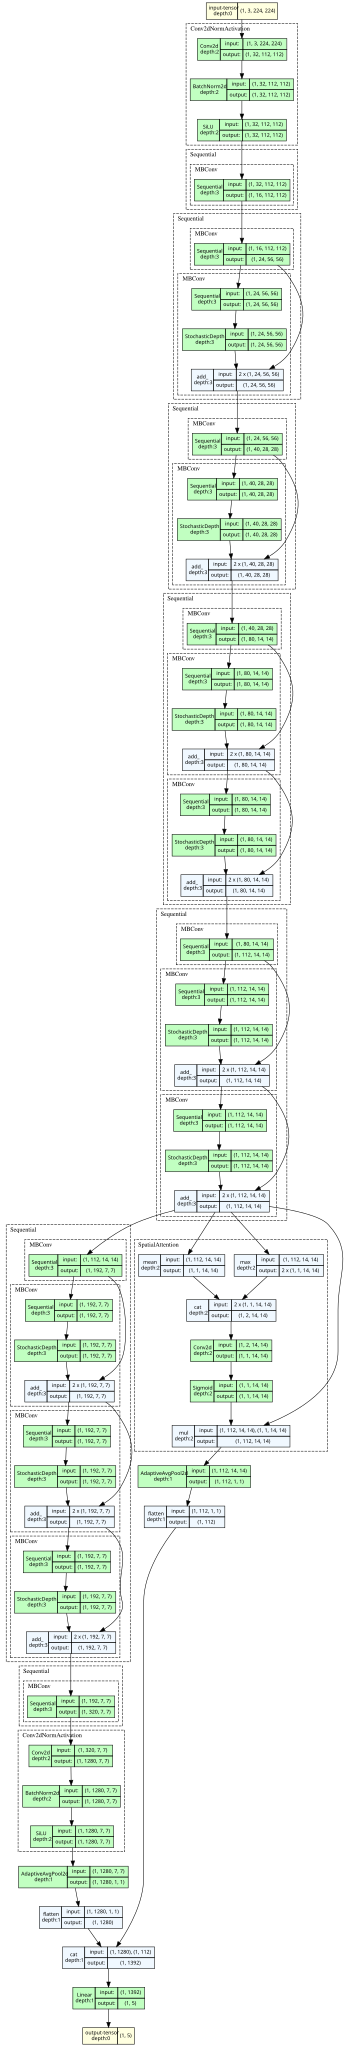

In [15]:
# Dummy input (can adjust shape based on your model's expected input)
dummy_input = torch.randn(1, 3, 224, 224, device=device)

# Generate the graph — expand_nested=True if model has nested submodules
model_graph = draw_graph(
    model,
    input_data=dummy_input,
    expand_nested=True,
    save_graph=False  # We don't want to save, only display inline
)

# Render to SVG and display inline in the notebook
svg_output = model_graph.visual_graph.pipe(format='svg')
display(SVG(svg_output))

In [16]:
def custom_metrics(y_pred, y_true, loss):
    y_pred_classes = torch.argmax(y_pred, dim=1)

    y_true_numpy = y_true.cpu().numpy()
    y_pred_classes_numpy = y_pred_classes.cpu().numpy()

    accuracy = accuracy_score(y_true_numpy, y_pred_classes_numpy)

    precision = precision_score(
        y_true_numpy, y_pred_classes_numpy,
        average='weighted', zero_division=0
    )

    recall = recall_score(
        y_true_numpy, y_pred_classes_numpy,
        average='weighted', zero_division=0
    )

    f1 = f1_score(
        y_true_numpy, y_pred_classes_numpy,
        average='weighted', zero_division=0
    )

    num_classes = y_pred.shape[1]
    auc_scores = []

    for class_idx in range(num_classes):
        class_y_true = (y_true_numpy == class_idx).astype(np.float32)
        class_y_pred = y_pred[:, class_idx].cpu().numpy()

        if np.unique(class_y_true).size < 2:
            continue

        try:
            auc_score = roc_auc_score(class_y_true, class_y_pred)
            auc_scores.append(auc_score)
        except ValueError:
            continue

    auc_avg = np.mean(auc_scores) if auc_scores else 0.0

    metrics = {
        "loss": loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "auc": auc_avg,
    }

    return metrics

In [17]:
# Hyperparameters
num_epochs = 30
initial_lr = 0.0006

# Criterion, optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=initial_lr)

# Plateau LR scheduler (fixed — no verbose arg)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.75,
    patience=5
)

In [18]:
metric_names = ["loss", "accuracy", "precision", "recall", "f1_score", "auc"]

train_metrics_history = {metric: [] for metric in metric_names}
val_metrics_history = {metric: [] for metric in metric_names}

best_val_loss = float("inf")

# Early Stopping
early_stopping_patience = 5
epochs_no_improve = 0
early_stop = False


# Training and validation loop
for epoch in range(num_epochs):

    # ===== TRAIN =====
    model.train()
    total_train_loss = 0.0
    all_train_predictions = []
    all_train_targets = []

    for data, targets in tqdm(train_loader, desc=f"Training Epoch [{epoch+1}/{num_epochs}]"):
        data = data.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        all_train_predictions.extend(outputs.detach().cpu().numpy())
        all_train_targets.extend(targets.detach().cpu().numpy())

    avg_train_loss = total_train_loss / len(train_loader)

    train_metrics = custom_metrics(
        torch.tensor(np.array(all_train_predictions)),
        torch.tensor(np.array(all_train_targets)),
        avg_train_loss
    )

    print("Train Metrics - " + ", ".join([f"{k}: {v:.4f}" for k, v in train_metrics.items()]))

    for metric in metric_names:
        train_metrics_history[metric].append(train_metrics[metric])


    # ===== VALIDATION =====
    model.eval()
    total_val_loss = 0.0
    all_val_predictions = []
    all_val_targets = []

    with torch.no_grad():
        for data, targets in tqdm(val_loader, desc="Validating Model"):
            data = data.to(device)
            targets = targets.to(device)

            outputs = model(data)
            loss = criterion(outputs, targets)

            total_val_loss += loss.item()
            all_val_predictions.extend(outputs.detach().cpu().numpy())
            all_val_targets.extend(targets.detach().cpu().numpy())

    avg_val_loss = total_val_loss / len(val_loader)

    val_metrics = custom_metrics(
        torch.tensor(np.array(all_val_predictions)),
        torch.tensor(np.array(all_val_targets)),
        avg_val_loss
    )

    print("Val Metrics - " + ", ".join([f"{k}: {v:.4f}" for k, v in val_metrics.items()]))

    for metric in metric_names:
        val_metrics_history[metric].append(val_metrics[metric])


    # ===== Save BEST model =====
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0

        torch.save(model.state_dict(),
                   "/kaggle/working/best_model_weights.pth")

        torch.save(model,
                   "/kaggle/working/best_model_full.pth")

        print("✅ Best model saved")

    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epoch(s)")


    # ===== Scheduler =====
    scheduler.step(avg_val_loss)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/{num_epochs} — ValLoss: {avg_val_loss:.4f} — LR: {current_lr:.6f}")


    # ===== Early Stopping Check =====
    if epochs_no_improve >= early_stopping_patience:
        print("🛑 Early stopping triggered!")
        break

Training Epoch [1/30]: 100%|██████████| 161/161 [02:05<00:00,  1.28it/s]


Train Metrics - loss: 0.6516, accuracy: 0.7577, precision: 0.7399, recall: 0.7577, f1_score: 0.7416, auc: 0.8937


Validating Model: 100%|██████████| 35/35 [00:28<00:00,  1.21it/s]


Val Metrics - loss: 0.5093, accuracy: 0.8106, precision: 0.8071, recall: 0.8106, f1_score: 0.7902, auc: 0.9231
✅ Best model saved
Epoch 1/30 — ValLoss: 0.5093 — LR: 0.000600


Training Epoch [2/30]: 100%|██████████| 161/161 [02:04<00:00,  1.29it/s]


...

Val Metrics - loss: 0.6127, accuracy: 0.8270, precision: 0.8298, recall: 0.8270, f1_score: 0.8212, auc: 0.9240
No improvement for 4 epoch(s)
Epoch 7/30 — ValLoss: 0.6127 — LR: 0.000600


Training Epoch [8/30]: 100%|██████████| 161/161 [01:57<00:00,  1.37it/s]


Train Metrics - loss: 0.1551, accuracy: 0.9419, precision: 0.9417, recall: 0.9419, f1_score: 0.9417, auc: 0.9867


Validating Model: 100%|██████████| 35/35 [00:25<00:00,  1.37it/s]

Val Metrics - loss: 0.6814, accuracy: 0.8434, precision: 0.8469, recall: 0.8434, f1_score: 0.8373, auc: 0.9188
No improvement for 5 epoch(s)
Epoch 8/30 — ValLoss: 0.6814 — LR: 0.000600
🛑 Early stopping triggered!


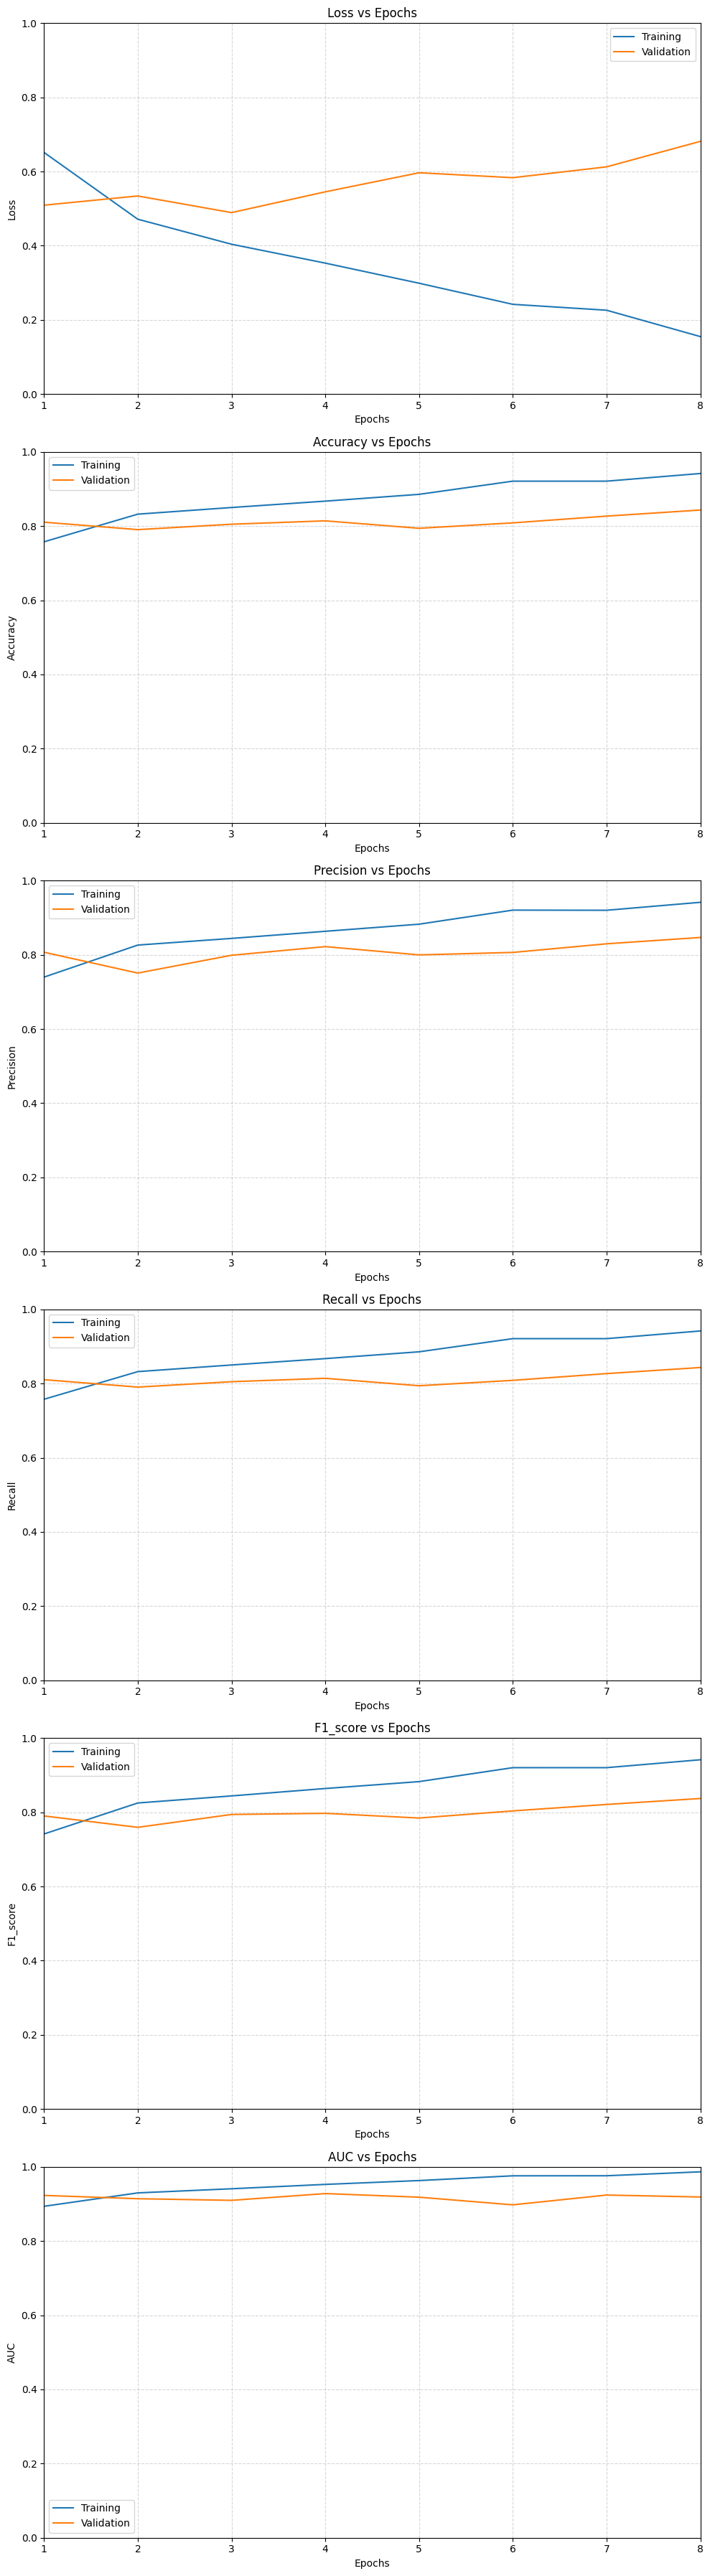

In [19]:
def plot_metrics(train_metrics_history, val_metrics_history, metric_names):
    num_metrics = len(metric_names)
    num_epochs = len(train_metrics_history[metric_names[0]])

    figure, axes = plt.subplots(num_metrics, figsize=(10, 6 * num_metrics))
    if num_metrics == 1:
        axes = [axes]

    rng = range(1, num_epochs + 1)

    for ax, metric_name in zip(axes, metric_names):
        train_metric = train_metrics_history[metric_name]
        val_metric = val_metrics_history[metric_name]

        ax.plot(rng, train_metric, label="Training")
        ax.plot(rng, val_metric, label="Validation")
        ax.legend()
        ax.set_xlabel("Epochs")

        if metric_name == "auc":
            ax.set_ylabel("AUC")
            ax.set_title("AUC vs Epochs")
        else:
            ax.set_ylabel(metric_name.capitalize())
            ax.set_title(f"{metric_name.capitalize()} vs Epochs")

        max_metric = max(max(train_metric), max(val_metric))
        min_metric = min(min(train_metric), min(val_metric))
        y_max = math.ceil(max_metric)

        if min_metric > 0 or max_metric > 1:
            ax.set_ylim(0, y_max)
        else:
            ax.set_ylim(min_metric, y_max)

        ax.grid(True, linestyle='--', alpha=0.5)

        if num_epochs == 1:
            ax.set_xlim(0.5, 1.5)
        else:
            ax.set_xlim(1, num_epochs)

    plt.tight_layout()
    plt.show()


plot_metrics(train_metrics_history, val_metrics_history, metric_names)

In [20]:
state_dict = torch.load("/kaggle/working/best_model_weights.pth")

model.load_state_dict(state_dict)
model = model.to(device)
model.eval()

print("✅ Best model loaded successfully")

✅ Best model loaded successfully


In [21]:
#model.eval()
total_test_loss = 0.0
all_test_predictions = []
all_test_targets = []

with torch.no_grad():
    for batch_idx, (data, targets) in enumerate(tqdm(test_loader, desc="Testing Model")):
        data = data.to(device)
        targets = targets.to(device)

        outputs = model(data)
        loss = criterion(outputs, targets)
        total_test_loss += loss.item()

        all_test_predictions.extend(outputs.detach().cpu().numpy())
        all_test_targets.extend(targets.detach().cpu().numpy())

all_test_predictions = np.array(all_test_predictions)
all_test_targets = np.array(all_test_targets)

average_test_loss = total_test_loss / len(test_loader)

test_metrics = custom_metrics(
    torch.tensor(all_test_predictions),
    torch.tensor(all_test_targets),
    average_test_loss
)

testing_metrics_line = "Test Metrics - " + ", ".join([f"{k}: {v:.4f}" for k, v in test_metrics.items()])
print(testing_metrics_line)

Testing Model: 100%|██████████| 35/35 [00:26<00:00,  1.33it/s]

Test Metrics - loss: 0.5131, accuracy: 0.8127, precision: 0.8100, recall: 0.8127, f1_score: 0.8060, auc: 0.9144


In [22]:
true_labels = np.array(all_test_targets)
predicted_labels = np.argmax(np.array(all_test_predictions), axis=1)

true_labels = true_labels.astype(int)
predicted_labels = predicted_labels.astype(int)

report = classification_report(
    true_labels,
    predicted_labels,
    target_names=CLASSES,
    digits=4
)

accuracy = accuracy_score(true_labels, predicted_labels)
num_errors = np.sum(true_labels != predicted_labels)

print(report)
print(f'There were {num_errors} errors in {len(predicted_labels)} tests for an accuracy of {accuracy * 100:6.2f}%')

                  precision    recall  f1-score   support

           No DR     0.9812    0.9631    0.9721       271
            Mild     0.6053    0.4107    0.4894        56
        Moderate     0.7081    0.8733    0.7821       150
          Severe     0.4138    0.4138    0.4138        29
Proliferative DR     0.6250    0.4545    0.5263        44

        accuracy                         0.8127       550
       macro avg     0.6667    0.6231    0.6367       550
    weighted avg     0.8100    0.8127    0.8060       550

There were 103 errors in 550 tests for an accuracy of  81.27%
